In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub as kh
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

%matplotlib inline

In [5]:
DOWNLOAD_PATH = "data"
DATASET = "aakash50897/churn-modellingcsv"
DATASET_FILE = "Churn_Modelling.csv"
TEST_SIZE = 0.2
RANDOM_STATE = 42

In [6]:
df_path = kh.dataset_download(DATASET, output_dir=DOWNLOAD_PATH)
df = pd.read_csv(f"{df_path}/{DATASET_FILE}")
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
le = LabelEncoder()

In [8]:
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

/var/folders/8s/hnrlcfv16rdb1gwgppl6tj1c0000gn/T/ipykernel_45660/2386425612.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [9]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [10]:
X = df.drop(columns=["Exited"])
y = df["Exited"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

In [12]:
scaler = StandardScaler()

In [13]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
model = Sequential()

In [15]:
model.add(Dense(units=10, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dense(units=10, activation="relu"))
model.add(Dense(units=1, activation="sigmoid"))

/Users/ccatlabuga/Documents/Personal/RNIP/lab1/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 231 (924.00 B)

 Trainable params: 231 (924.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [18]:
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7471 - loss: 0.5458 - val_accuracy: 0.8050 - val_loss: 0.4658
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step - accuracy: 0.7958 - loss: 0.4574 - val_accuracy: 0.8045 - val_loss: 0.4368
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step - accuracy: 0.8030 - loss: 0.4400 - val_accuracy: 0.8080 - val_loss: 0.4228
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step - accuracy: 0.8139 - loss: 0.4282 - val_accuracy: 0.8225 - val_loss: 0.4113
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step - accuracy: 0.8221 - loss: 0.4179 - val_accuracy: 0.8305 - val_loss: 0.4017
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - accuracy: 0.8295 - loss: 0.4071 - val_accuracy: 0.8415 - val_loss: 0.3905
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step - accuracy: 0.8420 - loss: 0.3933 - val_accuracy: 0.8480 - val_loss: 0.3768
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step - accuracy: 0.8479 - loss: 0.3801 - va

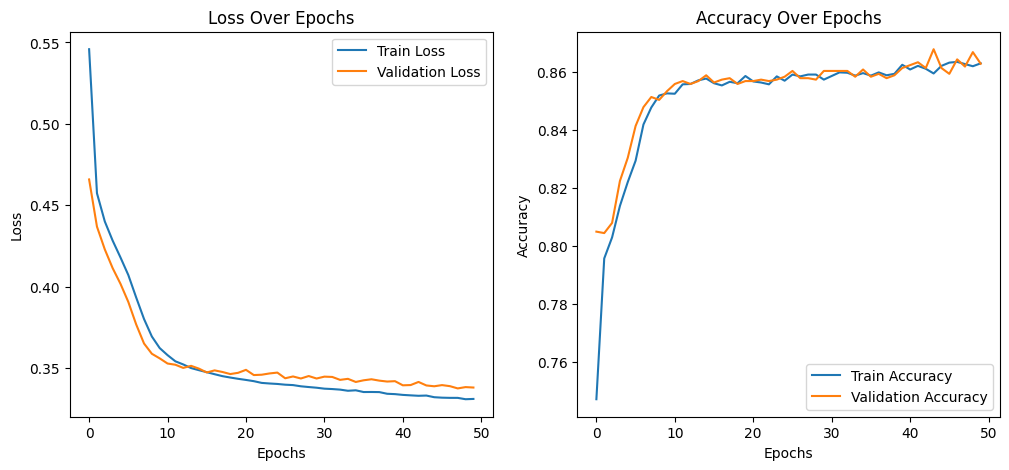

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

In [22]:
predictions = (model.predict(X_test) > 0.5).astype("int32")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [25]:
print("\n--- Evaluation Metrics ---")
print("Accuracy Score:", accuracy_score(y_test, predictions))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))


--- Evaluation Metrics ---
Accuracy Score: 0.863

Confusion Matrix:
 [[1539   68]
 [ 206  187]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.73      0.48      0.58       393

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [28]:
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights_dict)


Class Weights: {0: np.float64(0.6293266205160478), 1: np.float64(2.4330900243309004)}


In [32]:
optimized_model = Sequential()

In [33]:
optimized_model.add(BatchNormalization(input_shape=(X_train.shape[1],)))

optimized_model.add(Dense(units=128, activation="relu"))
optimized_model.add(Dropout(0.2))
optimized_model.add(BatchNormalization())

optimized_model.add(Dense(units=64, activation="relu"))
optimized_model.add(Dropout(0.2))
optimized_model.add(BatchNormalization())

optimized_model.add(Dense(units=32, activation="relu"))
optimized_model.add(Dense(units=1, activation="sigmoid"))

In [34]:
optimized_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_4           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,585 (49.16 KB)

 Trainable params: 12,181 (47.58 KB)

 Non-trainable params: 404 (1.58 KB)

In [35]:
optimized_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [36]:
optimized_model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), class_weight=class_weights_dict)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6676 - loss: 0.6018 - val_accuracy: 0.7375 - val_loss: 0.5188
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step - accuracy: 0.7179 - loss: 0.5460 - val_accuracy: 0.7470 - val_loss: 0.5044
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7340 - loss: 0.5236 - val_accuracy: 0.7600 - val_loss: 0.4656
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7436 - loss: 0.5112 - val_accuracy: 0.7585 - val_loss: 0.4751
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - accuracy: 0.7506 - loss: 0.5014 - val_accuracy: 0.7660 - val_loss: 0.4776
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7536 - loss: 0.4965 - val_accuracy: 0.7905 - val_loss: 0.4481
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step - accuracy: 0.7610 - loss: 0.4949 - val_accuracy: 0.7715 - val_loss: 0.4606
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7648 - loss: 0.4926 - val_accura

In [37]:
optimized_predictions = (optimized_model.predict(X_test) > 0.5).astype("int32")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step


In [39]:
print("\n--- Optimized Evaluation Metrics ---")
print("Accuracy Score:", accuracy_score(y_test, optimized_predictions))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, optimized_predictions))
print("\nClassification Report:\n", classification_report(y_test, optimized_predictions))


--- Optimized Evaluation Metrics ---
Accuracy Score: 0.7705

Confusion Matrix:
 [[1238  369]
 [  90  303]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.77      0.84      1607
           1       0.45      0.77      0.57       393

    accuracy                           0.77      2000
   macro avg       0.69      0.77      0.71      2000
weighted avg       0.84      0.77      0.79      2000

